# DQN — An Illustrated Tour

> **Deep Q-Network** replaces the Q-table with a neural network $Q_\theta(s, a)$. Two tricks make it stable: a **replay buffer** and a slowly-updated **target network**.

---

**What we cover:**
- The CartPole problem in gymnasium
- Q-network architecture & loss
- Experience replay (decorrelate transitions)
- Target network (frozen bootstrap target)
- Training reward curve and final policy
- Visualising $Q(s, \cdot)$ along a trajectory

## The picture — same loop, but Q is a neural network over states

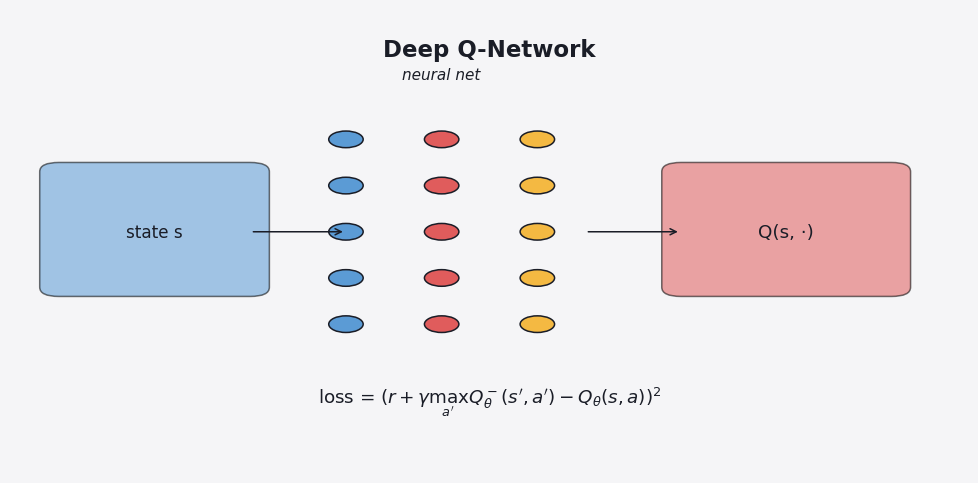

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
fig, ax = plt.subplots(figsize=(9, 4.5)); ax.axis('off')
ax.text(0.5, 0.9, 'Deep Q-Network', ha='center', fontsize=15, weight='bold')
ax.add_patch(FancyBboxPatch((0.05, 0.4), 0.20, 0.25, boxstyle='round,pad=0.02',
                            facecolor=P[0], alpha=0.55))
ax.text(0.15, 0.52, 'state s', ha='center', va='center', fontsize=11)
# NN layers
for i, x in enumerate([0.35, 0.45, 0.55]):
    for j, y in enumerate(np.linspace(0.32, 0.72, 5)):
        ax.add_patch(Circle((x, y), 0.018, color=P[i % 4], ec='#1a1d27'))
ax.text(0.45, 0.85, 'neural net', ha='center', fontsize=10, style='italic')
ax.add_patch(FancyBboxPatch((0.70, 0.4), 0.22, 0.25, boxstyle='round,pad=0.02',
                            facecolor=P[1], alpha=0.55))
ax.text(0.81, 0.52, 'Q(s, ·)', ha='center', va='center', fontsize=12)
ax.annotate('', xy=(0.35, 0.52), xytext=(0.25, 0.52),
            arrowprops=dict(arrowstyle='->', color='#1a1d27'))
ax.annotate('', xy=(0.70, 0.52), xytext=(0.60, 0.52),
            arrowprops=dict(arrowstyle='->', color='#1a1d27'))
ax.text(0.5, 0.15, r"loss = $(r + \gamma \max_{a'} Q_\theta^-(s',a') - Q_\theta(s,a))^2$",
        ha='center', fontsize=12)
plt.tight_layout(); plt.show()


In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import gymnasium as gym
from collections import deque
import random

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':17,'axes.labelsize':13,
    'xtick.labelsize':11,'ytick.labelsize':11,'legend.fontsize':11,'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4','figure.dpi':120,
}
plt.rcParams.update(PLT_STYLE)
C0='#5b9bd5'; C1='#e05c5c'; CB='#f4b942'; CM='#7ecba1'

torch.manual_seed(0); np.random.seed(0); random.seed(0)
device = 'cpu'
env = gym.make('CartPole-v1')
n_obs = env.observation_space.shape[0]
n_act = env.action_space.n
print('CartPole obs dim:', n_obs, 'actions:', n_act)

CartPole obs dim: 4 actions: 2


---
## Q-Network and Loss

The network $Q_\theta(s)$ outputs one scalar per action. Training minimises

$$\mathcal{L}(\theta) = \mathbb{E}_{(s,a,r,s') \sim \mathcal{D}}\Bigl[\bigl(r + \gamma \max_{a'} Q_{\theta^-}(s', a') - Q_\theta(s, a)\bigr)^2\Bigr],$$

where $\mathcal{D}$ is the replay buffer and $\theta^-$ are the **target network** parameters — a frozen copy of $\theta$ refreshed every few hundred steps. Both tricks decorrelate the gradient signal and prevent the moving-target instability of vanilla TD with neural nets.

In [3]:
class QNet(nn.Module):
    def __init__(self, n_in, n_out, h=64):
        super().__init__()
        self.f = nn.Sequential(nn.Linear(n_in, h), nn.ReLU(),
                                nn.Linear(h, h), nn.ReLU(),
                                nn.Linear(h, n_out))
    def forward(self, x): return self.f(x)

qnet  = QNet(n_obs, n_act).to(device)
qtgt  = QNet(n_obs, n_act).to(device)
qtgt.load_state_dict(qnet.state_dict())
opt = torch.optim.Adam(qnet.parameters(), lr=1e-3)
buffer = deque(maxlen=20000)
gamma = 0.99; batch = 64

def select_action(s, eps):
    if random.random() < eps: return env.action_space.sample()
    with torch.no_grad():
        return int(qnet(torch.tensor(s, dtype=torch.float32)).argmax().item())

def learn():
    if len(buffer) < batch: return
    samples = random.sample(buffer, batch)
    s, a, r, s2, d = map(np.array, zip(*samples))
    s  = torch.tensor(s, dtype=torch.float32)
    a  = torch.tensor(a, dtype=torch.long)
    r  = torch.tensor(r, dtype=torch.float32)
    s2 = torch.tensor(s2, dtype=torch.float32)
    d  = torch.tensor(d, dtype=torch.float32)
    q  = qnet(s).gather(1, a.unsqueeze(1)).squeeze(1)
    with torch.no_grad():
        q2 = qtgt(s2).max(1)[0]
        target = r + gamma * q2 * (1 - d)
    loss = F.smooth_l1_loss(q, target)
    opt.zero_grad(); loss.backward()
    nn.utils.clip_grad_norm_(qnet.parameters(), 10.0)
    opt.step()

In [4]:
n_episodes = 250
rewards = []
global_step = 0
for ep in range(n_episodes):
    s, _ = env.reset(seed=ep)
    eps = max(0.05, 1.0 - ep / 80)
    total = 0.0
    for t in range(500):
        a = select_action(s, eps)
        s2, r, term, trunc, _ = env.step(a)
        done = term or trunc
        buffer.append((s, a, r, s2, float(term)))
        s = s2; total += r; global_step += 1
        learn()
        if global_step % 250 == 0:
            qtgt.load_state_dict(qnet.state_dict())
        if done: break
    rewards.append(total)
print('Final 25-ep mean return:', np.mean(rewards[-25:]))

Final 25-ep mean return: 136.6


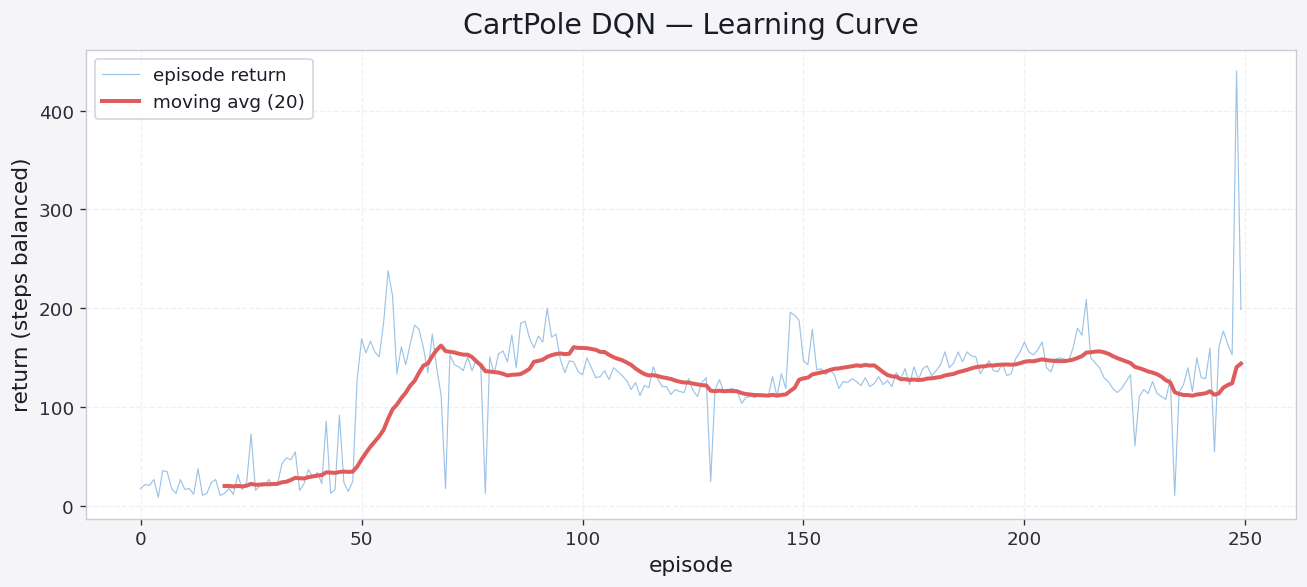

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(rewards, color=C0, lw=0.7, alpha=0.6, label='episode return')
w = 20
ax.plot(np.arange(w-1, len(rewards)),
        np.convolve(rewards, np.ones(w)/w, 'valid'),
        color=C1, lw=2.4, label=f'moving avg ({w})')
ax.set_xlabel('episode'); ax.set_ylabel('return (steps balanced)')
ax.set_title('CartPole DQN — Learning Curve', pad=10)
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

---
## $Q(s, \cdot)$ Along a Trained Trajectory

Greedy roll-out with the trained net. Plot the two action-values over time — they should **track each other**, with the chosen action's curve sitting on top.

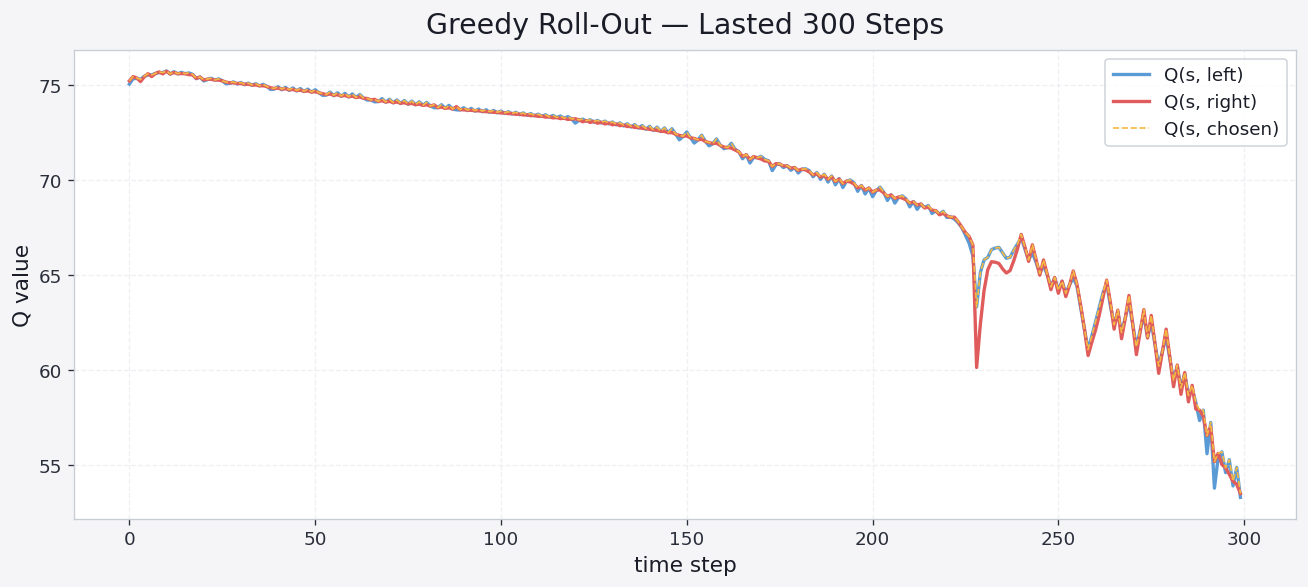

In [6]:
s, _ = env.reset(seed=999)
qs = []; acts = []
for _ in range(300):
    with torch.no_grad():
        q = qnet(torch.tensor(s, dtype=torch.float32))
    qs.append(q.numpy()); a = int(q.argmax()); acts.append(a)
    s, _, term, trunc, _ = env.step(a)
    if term or trunc: break
qs = np.asarray(qs); acts = np.asarray(acts)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(qs[:, 0], color=C0, lw=2, label='Q(s, left)')
ax.plot(qs[:, 1], color=C1, lw=2, label='Q(s, right)')
ax.plot(qs[np.arange(len(acts)), acts], color=CB, lw=1, ls='--', label='Q(s, chosen)')
ax.set_xlabel('time step'); ax.set_ylabel('Q value')
ax.set_title(f'Greedy Roll-Out — Lasted {len(acts)} Steps', pad=10)
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

---
## ⚖️ When to use DQN — and when not to

| Situation | DQN | Policy Gradient | A2C / PPO | Tabular Q-Learning |
|---|---|---|---|---|
| Discrete action space | ✅ | ✅ | ✅ | ✅ |
| Continuous actions | ❌ | ✅ | ✅ | ❌ |
| Pixels / large state | ✅ | ✅ | ✅ | ❌ |
| Stable on small problems | partial (replay + target) | ❌ noisy | ✅ | ✅ |

> DQN is the **canonical deep RL algorithm** for discrete-action problems. For continuous actions reach for SAC, TD3, or PPO.


---
## 🎯 Try this

1. **Ablate replay.** Set buffer size to 1 (no replay) — training should destabilise. The buffer breaks correlation in the data stream.
2. **Ablate the target net.** Use the live network as the target — Q-values diverge ("deadly triad"). Restore the target net and observe stability return.
3. **Double DQN.** Replace $\max_{a'}Q_\text{tgt}(s', a')$ with $Q_\text{tgt}(s', \arg\max_{a'}Q_\theta(s', a'))$. Reduces over-estimation bias for free.


---
## Summary

| Concept | Description | Key Insight |
|---|---|---|
| Q-network | $Q_\theta(s) \in \mathbb{R}^{|\mathcal{A}|}$ | Generalises across states |
| Loss | TD error squared | Smooth L1 (Huber) is more stable |
| Replay buffer | Sample minibatches of past transitions | Breaks temporal correlation |
| Target network | Frozen copy of $\theta$, refreshed periodically | Stabilises bootstrap |
| $\varepsilon$-decay | Anneal exploration | High at start, low at the end |
| Strength | Scales tabular Q-learning to continuous states | Works on Atari from raw pixels |
| Weakness | Overestimates Q (use Double-DQN); discrete actions only | Continuous → DDPG/SAC |

**Bottom line:** DQN = Q-learning + neural net + replay buffer + target net. Those four ingredients turn a finicky table-update loop into a stable function approximator that can balance a pole, play Atari, or pilot a quad-rotor.